In [134]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import weighted_average
import numpy as np
import mat73
import math
import scipy.io as sp
import sys

# Directory and file names for each Matlab dataset
# fdir = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2025_10_27_050000_051500/"
# fb450 = "Band_450nm_BFS-PGE-16S7M_SN22245818/Langley_plots/Band_450nm_BFS-PGE-16S7M_SN22245818_Langley_20251028_050003.mat"
# fb450 = "Band_470nm_BFS-PGE-16S7M_SN22245821/Langley_plots/Band_470nm_BFS-PGE-16S7M_SN22245821_Langley_20251028_050003.mat"
# fb450 = "Band_490nm_BFS-PGE-16S7M_SN22010605/Langley_plots/Band_490nm_BFS-PGE-16S7M_SN22010605_Langley_20251028_050003.mat"
# fb450 = "Band_520nm_BFS-PGE-16S7M_SN22011988/Langley_plots/Band_520nm_BFS-PGE-16S7M_SN22011988_Langley_20251028_050003.mat"
# fname = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Band_450nm_BFS-PGE-16S7M_SN22245818/Langley_plots/Band_450nm_BFS-PGE-16S7M_SN22245818_Langley_20251028_030002.mat"
# fname = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2025_10_27_030000_040000/Band_520nm_BFS-PGE-16S7M_SN22011988/Langley_plots/Band_520nm_BFS-PGE-16S7M_SN22011988_Langley_20251028_030003.mat"
fb520 = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2025_10_27_030000_060000/Band_450nm_BFS-PGE-16S7M_SN22245818/Langley_plots/Band_450nm_BFS-PGE-16S7M_SN22245818_Langley_20251028_030002.mat"
fb490 = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2025_10_27_030000_060000/Band_470nm_BFS-PGE-16S7M_SN22245821/Langley_plots/Band_470nm_BFS-PGE-16S7M_SN22245821_Langley_20251028_030004.mat"
fb470 = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2025_10_27_030000_060000/Band_490nm_BFS-PGE-16S7M_SN22010605/Langley_plots/Band_490nm_BFS-PGE-16S7M_SN22010605_Langley_20251028_030003.mat"
fb450 = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2025_10_27_030000_060000/Band_520nm_BFS-PGE-16S7M_SN22011988/Langley_plots/Band_520nm_BFS-PGE-16S7M_SN22011988_Langley_20251028_030003.mat"

Read the Matlab data

In [135]:
loc = 'all_res'
band = input("band: ")
if band == '450':
    b450 = sp.loadmat(fb450)[loc][0,:]
    b450 = pd.DataFrame(b450)
elif band == '470':
    b450 = sp.loadmat(fb470)[loc][0,:]
    b450 = pd.DataFrame(b450)
elif band == '490':
    b450 = sp.loadmat(fb490)[loc][0,:]
    b450 = pd.DataFrame(b450)
elif band == '520':
    b450 = sp.loadmat(fb520)[loc][0,:]
    b450 = pd.DataFrame(b450)
else:
    print("Invalid band")
    sys.exit()


# Create array to map data onto
nframes = 90 # hardcoded from 05:00:00 to 05:15:00 Local Time(?)
frames = np.arange(1,nframes+1)

## All-Star Langley Plot

/var/folders/hx/hcs55bp10f5fdvcmjf0rmf4r0000gn/T/ipykernel_35168/4116921674.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x, y,


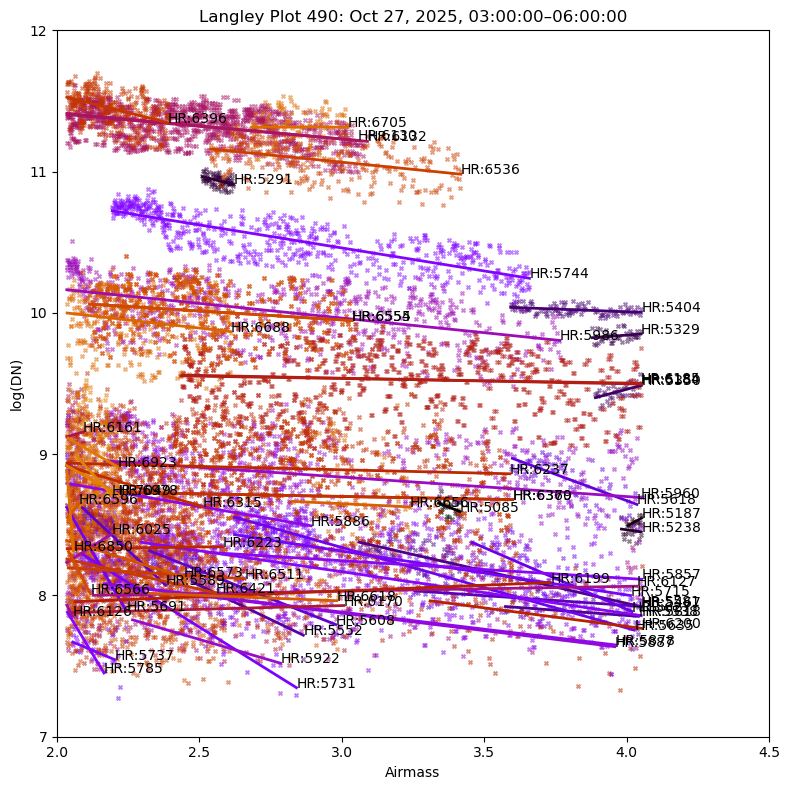

In [ ]:
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(8,8))

star_ids = b450['hr']
colors = cm.gnuplot(np.linspace(0,0.8,len(b450)))

# Might be terrible coding, but this is how I'm doin it:
star_ids = star_ids.map(lambda x: x[0][0] if isinstance(x, np.uint16) else x[0][0])
b450['hr'] = star_ids.values

for (star_id, group), color in zip(b450.groupby('hr'), colors):
    x = group['airmass'].values[0].T[0]     # secant(theta)
    y = group['log_DN'].values[0].T[0]      # ln(DN)
    m = group['slope'].values[0].T[0]       # Slope ( tau )
    b = group['intercept'].values[0].T[0]   # intercept ( ln(I0) )

    # Check this error analysis method!
    N = len(x)
    sigmax = np.std(x)          # standard deviation of Airmass
    sigmay = np.std(y)          # standard deviation of ln(DN)
    sigmam = sigmay / (np.sqrt(N) * sigmax)

    # plot star_i DN's
    ax.scatter(x, y, 
        label=rf'HR={star_id}; $\tau$={np.round(m[0],3):04}$\pm${np.round(sigmam,3)}; $I_0$={np.round(b[0],2)}',
        c=color,
        s=7.5, 
        marker='x', 
        alpha=0.5, 
        # edgecolors='black', 
        # linewidths=0.1
    )

    # plot star_i slope and intercept
    ax.plot(x, m*x+b,
        c=color,
        linestyle='-',
        linewidth='2',
    )    

    # Label each star on the plot
    ax.annotate(
        text=f'HR:{star_id}',
        xy=(x[len(x)-1],m*x[len(x)-1]+b),
        # xy=(x[0],m*x[0]+b),
    )


ax.set_xlabel(fr'Airmass')
ax.set_ylabel(fr'log(DN)')
ax.set_title(fr'Langley Plot {band}: Oct 27, 2025, 03:00:00–06:00:00')
ax.set_xlim(2., 4.5)
ax.set_ylim(7, 12)
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='5')
# ax.grid()
plt.tight_layout()
plt.savefig(f'./b{band}_langley_all_0300000_060000.png',format='png', dpi=300)
plt.close()


## Star Grid
### For Friday Morning!
- Compute each best-fit line using np.polyfit degree 1?
- Return the variance from this to use for weighting with 1/$\sigma^2$
- add a variance column / row to the dataframe for future use / filtering?

In [ ]:
# Make a grid of plots!
nstars = len(b450)
nrows = math.floor(np.sqrt(nstars))
ncols = math.ceil(np.sqrt(nstars))
# X, Y = np.meshgrid(np.arange(nrows), np.arange(ncols))
# frame_arr = np.array([list(zip(row1, row2)) for row1, row2 in zip(X, Y)])

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15,15))

# Loop through each star
row, col = 0, 0
cond = True
for star_id, group in b450.groupby('hr'):
    axis = (row, col)

    # Get salient arrays
    x = group['airmass'].values[0].T[0]     # secant(theta)
    y = group['log_DN'].values[0].T[0]      # ln(DN)
    m = group['slope'].values[0].T[0]       # Slope ( tau )
    b = group['intercept'].values[0].T[0]   # intercept ( ln(I0) )
    
    # Use np.polyfit data
    p, cov = np.polyfit(x, y, 1, cov=True)
    m = p[0]
    b = p[1]
    sigmam = cov[0, 0]
    sigmab = cov[1, 1]

    ax[axis].scatter(
        x,
        y,
        marker='o',
        c='black',
        s=8,
        alpha=0.4,
    )

    ax[axis].plot(
        x,
        m*x+b,
        color='red',
        linewidth=2
    )

    ax[axis].tick_params(axis='both', labelsize=6)
    ax[axis].set_title(fr'HR:{star_id} $\tau$={np.round(m,3)}$\pm${np.round(sigmam,5)}', fontsize=8)

    if (col == ncols-1) & (row == nrows-1):
        break
    if row < nrows-1:
        row += 1
    elif row == nrows-1:
        row = 0
        col += 1

plt.tight_layout()
# plt.savefig(f'./b{band}_all_stars_030000-060000.png', format='png', dpi=400)
plt.close()

## Star Statistics 
First, filter out data that has $\tau\geq 0$, then:
<br><br>
get TIME-NORMALIZED # of points!


/var/folders/hx/hcs55bp10f5fdvcmjf0rmf4r0000gn/T/ipykernel_35168/2760004760.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


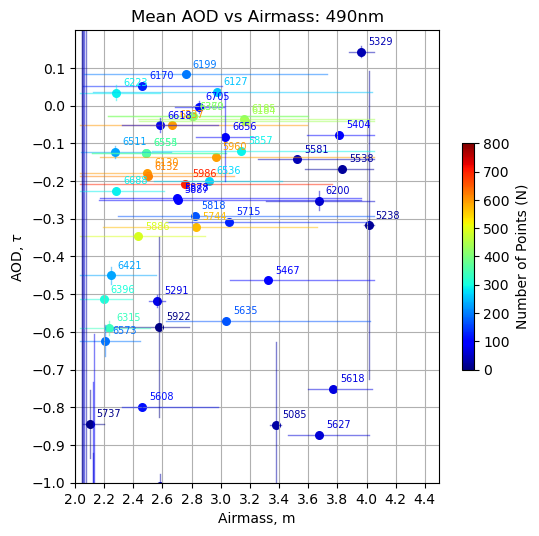

In [138]:
from matplotlib.colors import Normalize
import seaborn as sns
from matplotlib.gridspec import GridSpec

# AOD vs Airmass

nstars = len(b450)
nrows = np.floor(np.sqrt(nstars))
ncols = np.ceil(np.sqrt(nstars))

# Normalize the color range

norm = Normalize(vmin=0, vmax=800)  # range of # points (0 to 800)
sm = plt.cm.ScalarMappable(cmap=cm.jet, norm=norm)
sm.set_array([])  # for ScalarMappable

# Colors for number of points
colors = cm.jet(np.linspace(0, 1, 800))

# fig, ax = plt.subplots(nrows, ncols, figsize=(12,12))
fig = plt.figure(figsize=(8,8))
gs = GridSpec(4, 4, figure=fig, hspace=0.3, wspace=0.3)

ax_main = fig.add_subplot(gs[1:, :-1])

row, col = 0, 0
data = []
for star_id, group in b450.groupby('hr'):

    # Get salient arrays
    x = group['airmass'].values[0].T[0]     # secant(theta)
    y = group['log_DN'].values[0].T[0]      # ln(DN)
    # m = group['slope'].values[0].T[0]       # Slope ( tau )
    # b = group['intercept'].values[0].T[0]   # intercept ( ln(I0) )
    
    p, cov = np.polyfit(x, y, 1, cov=True)
    m = p[0]
    b = p[1]
    sigmam = cov[0, 0]
    sigmab = cov[1, 1]

    # Colors based on # of valid points
    N = len(x[~np.isnan(x)])    # Number of valid points across Airmass
    color = colors[N]

    # Plot individual star's AOD and Airmass
    ax_main.scatter(
        x.mean(),
        m,
        label=fr'HR{star_id}',
        s=30,
        c=[color],  # Wrap color in a list
    )

    # Plot the range of Airmasses 
    ax_main.plot(
        [x.min(), x.max()],
        [m, m],
        color=color,
        linewidth=1,
        alpha=0.5
    )


    # Plot the variance in AOD
    ax_main.plot(
        [x.mean(), x.mean()],
        [m-sigmam, m+sigmam],
        color=color,
        linewidth=1,
        alpha=0.5
    )

    ax_main.annotate(
        text=f'{star_id}',
        xy=(x.mean(), m),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=7,
        color=color
    )

    # Append those statistics
    data.append({
        'airmass': x.mean(),
        'tau': m,
        'N': N
    })

# Random x and y axis stuff
xmin, xmax = 2.0, 4.5
ymin, ymax = -1., 0.2
ax_main.set_xlabel("Airmass, m")
ax_main.set_ylabel(fr"AOD, $\tau$")
ax_main.grid()

# Add the colorbar
cbar = plt.colorbar(sm, ax=ax_main, shrink=0.5, location='right', orientation='vertical')
cbar.set_label('Number of Points (N)')

ax_main.set_xlim(xmin, xmax)
ax_main.set_ylim(ymin, ymax)
ax_main.set_yticks(np.arange(ymin, ymax, 0.1))
ax_main.set_xticks(np.arange(xmin, xmax, 0.2))

ax_main.set_title(f'Mean AOD vs Airmass: {band}nm')

plt.tight_layout()

plt.savefig(f'./b{band}_aod_vs_airmass.png',format='png',dpi=300)
plt.show()
plt.close()

    

/var/folders/hx/hcs55bp10f5fdvcmjf0rmf4r0000gn/T/ipykernel_35168/1823165457.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


Text(0, 0.5, 'ln(DN) std: $\\sigma_y$')

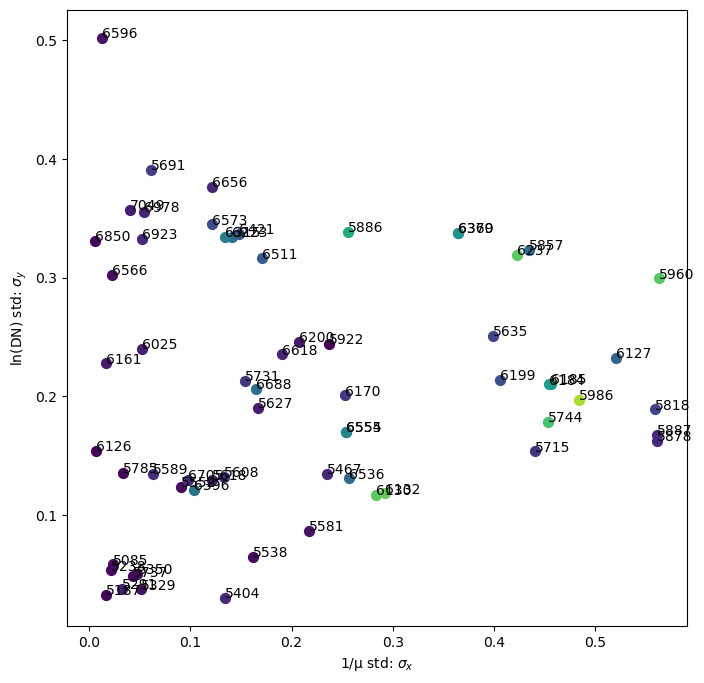

In [139]:
# Filter out data if tau >= 0:
# b450 = b450[b450['slope'] < 0]
nstars = len(b450)
nrows = np.floor(np.sqrt(nstars))
ncols = np.ceil(np.sqrt(nstars))

# Colors for points
colors = cm.viridis(np.linspace(0,1,800))

# fig, ax = plt.subplots(nrows, ncols, figsize=(12,12))
fig, ax = plt.subplots(1, 1, figsize=(8,8))

row, col = 0, 0
for star_id, group in b450.groupby('hr'):

        # Get salient arrays
        x = group['airmass'].values[0].T[0]     # secant(theta)
        y = group['log_DN'].values[0].T[0]      # ln(DN)
        m = group['slope'].values[0].T[0]       # Slope ( tau )
        b = group['intercept'].values[0].T[0]   # intercept ( ln(I0) )

        # Compute the weighted average of each star
        N = len(x[~np.isnan(x)])    # Number of valid points across Airmass
        sigmax = np.std(x)          # standard deviation of Airmass
        sigmay = np.std(y)          # standard deviation of ln(DN)
        sigmam = sigmay / (np.sqrt(N) * sigmax)

        # Color denotes the number of points:
        color = colors[N]

        ax.scatter(
                sigmax,
                sigmay, 
                label=fr'HR:{star_id}',
                c=color,
                s=50
        )

        ax.annotate(
                f'{star_id}',
                xy=(sigmax,sigmay)
        )

ax.set_xlabel(fr'1/µ std: $\sigma_x$')
ax.set_ylabel(fr'ln(DN) std: $\sigma_y$')


## Variance Statistics
- var vs # points
- var vs airmass range
- var vs star TOA brightness

: 

: 

: 